First we need to import all the necessary libaries. We will be using the numpy, seaborn and matplotlib libraries to complete visuals

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

We will be loading the dataset from my GitHub repository to allow for code execution without needing to save the dataset locally. Also, becasue the dataset is separated by spaces I will need to use delim_whitespace

In [4]:
df = pd.read_csv('https://github.com/KcirtapdiaZ/IS_362_Data_Acquisition_and_Mgmt/raw/main/auto-mpg.data', delim_whitespace=True, header=None)
df.head()

C:\Users\Patri\AppData\Local\Temp\ipykernel_14212\1931395391.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('https://github.com/KcirtapdiaZ/IS_362_Data_Acquisition_and_Mgmt/raw/main/auto-mpg.data', delim_whitespace=True, header=None)


,0,1,2,3,4,5,6,7,8
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


As we can see above the data does not tell us what the columns are so we'll clean that up below and assign column names

In [5]:
df.columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'car_name']
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


We have some data that needs to be cleaned up in the "horsepower" column. We'll use .replace to update the "?" in that column.

In [10]:
df["horsepower"] = df["horsepower"].replace(r"\?", np.nan, regex=True)
df["horsepower"] = pd.to_numeric(df["horsepower"])
df["horsepower"]

0      130.0
1      165.0
2      150.0
3      150.0
4      140.0
       ...  
393     86.0
394     52.0
395     84.0
396     79.0
397     82.0
Name: horsepower, Length: 398, dtype: float64

The above code cleans up the horsepower column, now we'll clean the origin column to convert the numbers to the respcetive continents. We will use .replace for this as well

In [11]:
df["origin"] = df["origin"].replace({1: "USA", 2: "Europe", 3: "Japan"})
df["origin"]

0         USA
1         USA
2         USA
3         USA
4         USA
        ...  
393       USA
394    Europe
395       USA
396       USA
397       USA
Name: origin, Length: 398, dtype: object

The first chart we will be creating is a bar chart based on the car cylinders. This shows that there are substancially more cars with 4 cylinders and any other

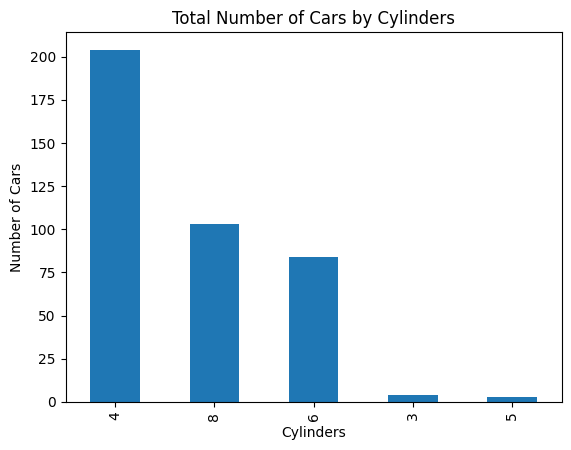

In [13]:
df["cylinders"].value_counts().plot(kind="bar")
plt.title("Total Number of Cars by Cylinders")
plt.xlabel("Cylinders")
plt.ylabel("Number of Cars")
plt.show()

Next we will be creating a scatterplot based on the horsepower and weight. This shows that cars that are heavier tend to have more horsepower

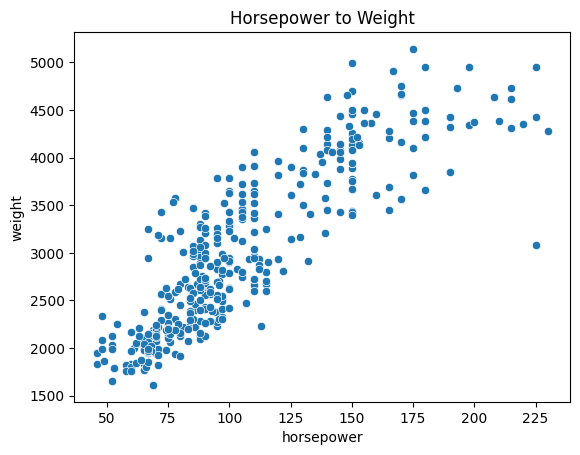

In [15]:
sns.scatterplot(data=df, x="horsepower", y="weight")
plt.title("Horsepower to Weight")
plt.show()

My question is: Are cars with less cylinders more fuel efficient?
A boxplot would be the best becasue it shows the median mpg across the different cylinders and also shows the outliers for those cylinders. Based on the boxplot we can clearly see that 4 cylinders offers more mpg

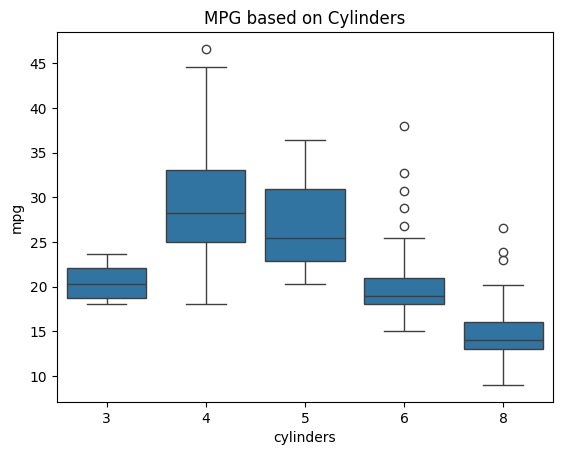

In [18]:
sns.boxplot(data=df, x="cylinders", y="mpg")
plt.title("MPG based on Cylinders")
plt.show()